First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   

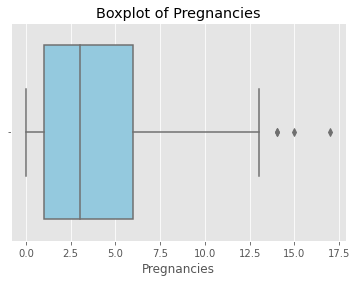

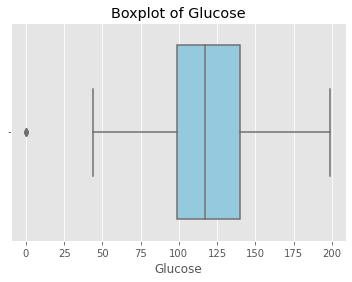

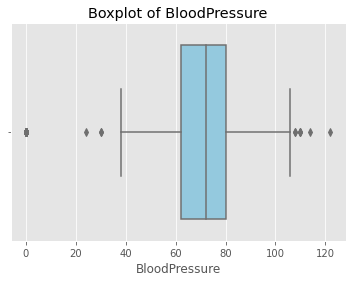

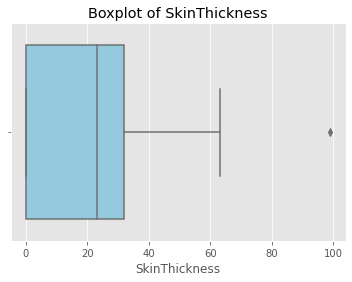

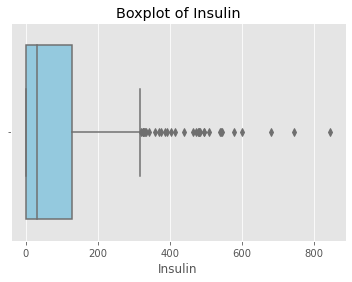

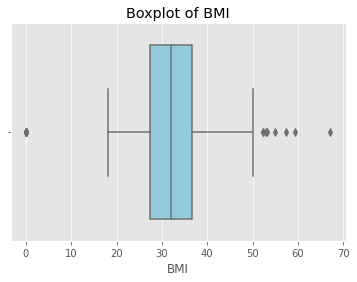

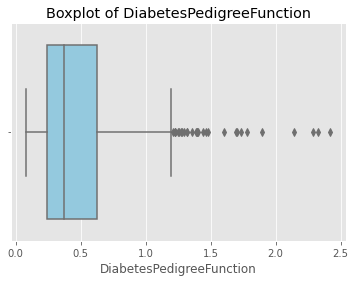

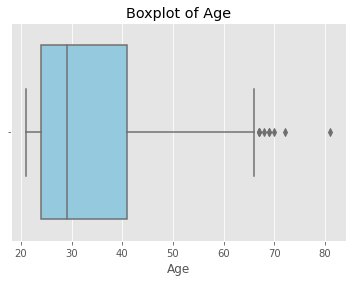

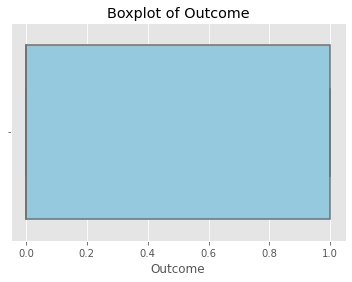

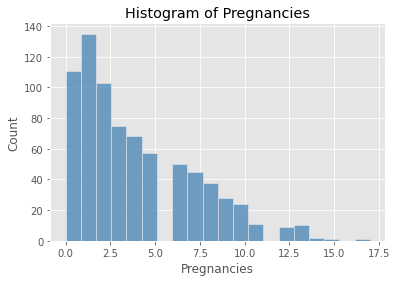

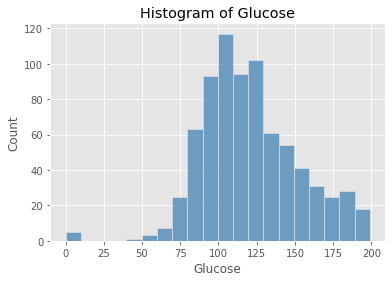

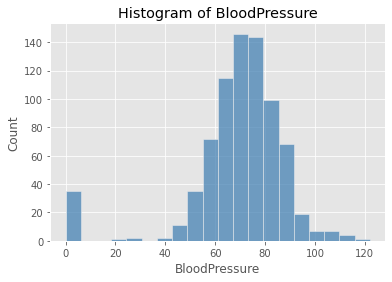

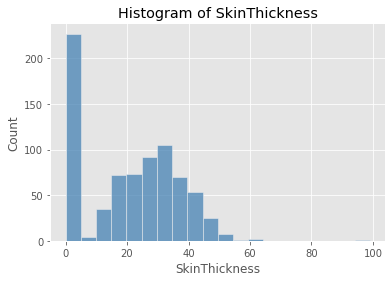

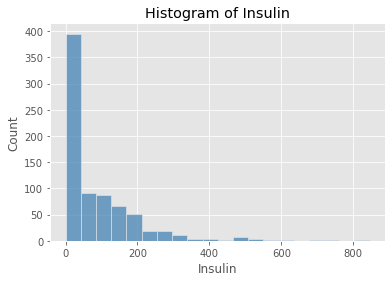

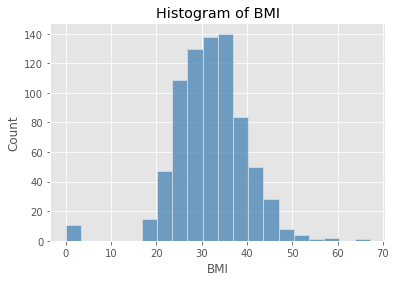

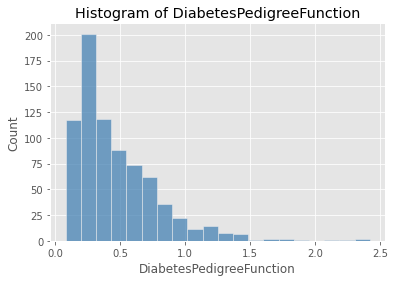

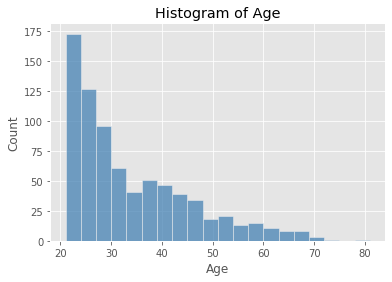

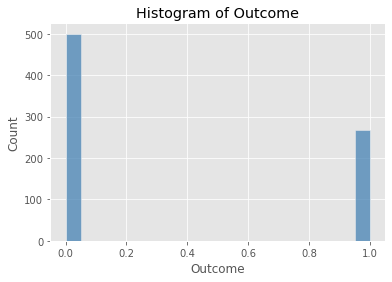

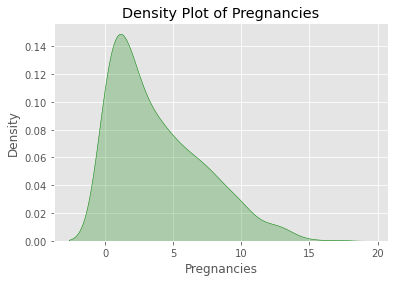

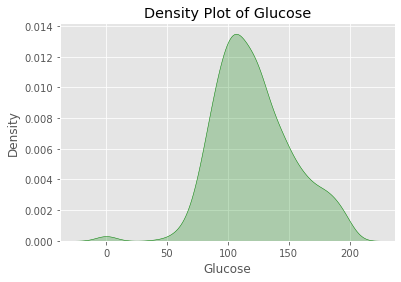

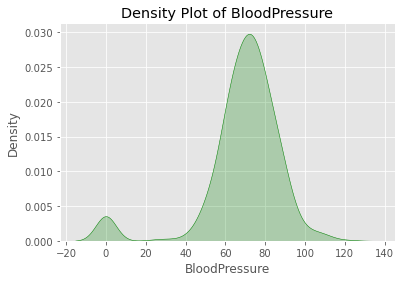

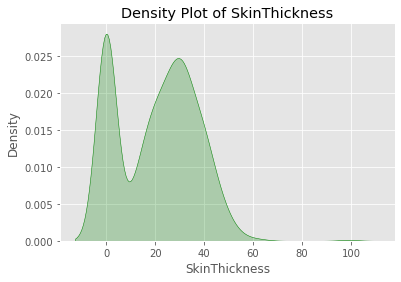

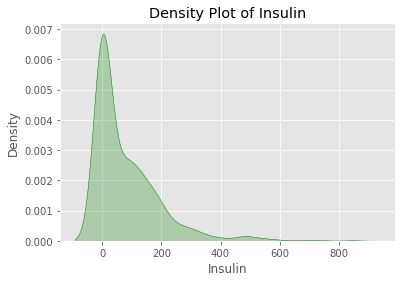

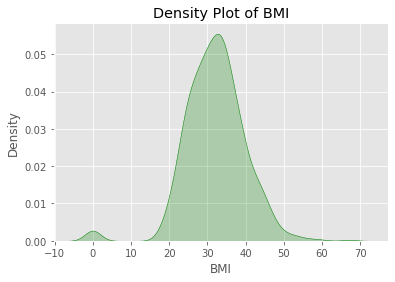

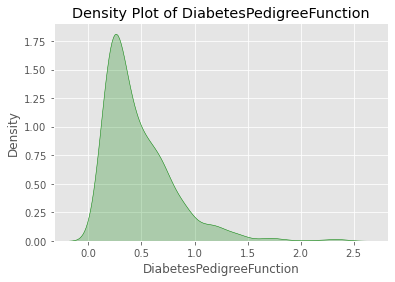

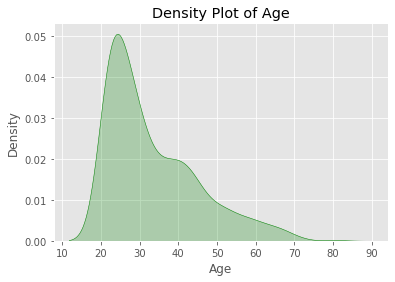

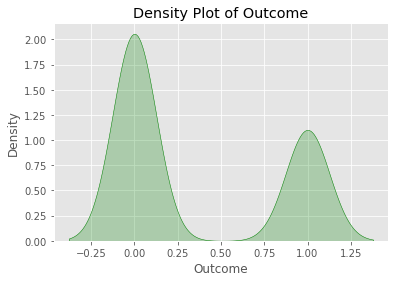

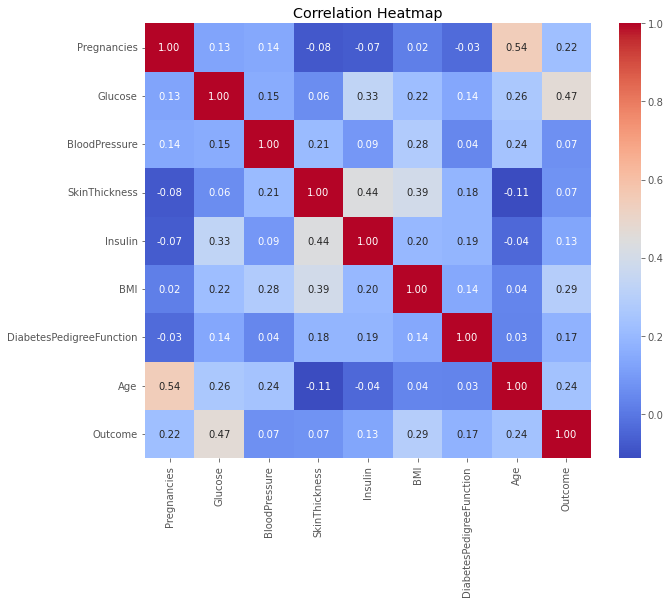

In [ ]:

!pip install pandas numpy scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation, probplot

plt.style.use('ggplot')

df = pd.read_csv("diabetes_dataset.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


num_df = df.select_dtypes(include=np.number)

print("\nNumerical Columns:")
print(num_df.columns)


print("\n===== Mean =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].mean()}")

print("\n===== Median =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].median()}")

print("\n===== Trimmed Mean =====")
for col in num_df.columns:
    print(f"{col}: {trim_mean(num_df[col].dropna(),0.10)}")

print("\n===== Weighted Mean =====")
for col in num_df.columns:
    data = num_df[col].dropna()
    weights = np.arange(1,len(data)+1)
    print(f"{col}: {np.average(data,weights=weights)}")


print("\n===== Range =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].max()-num_df[col].min()}")

print("\n===== Variance =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].var()}")

print("\n===== Standard Deviation =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].std()}")

print("\n===== IQR =====")
for col in num_df.columns:
    Q1=num_df[col].quantile(0.25)
    Q3=num_df[col].quantile(0.75)
    print(f"{col}: {Q3-Q1}")

print("\n===== MAD =====")
for col in num_df.columns:
    print(f"{col}: {median_abs_deviation(num_df[col].dropna())}")


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col],color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=20,kde=False,color="steelblue")
    plt.title(f"Histogram of {col}")
    plt.show()

for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col],fill=True,color="green")
    plt.title(f"Density Plot of {col}")
    plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


if "Outcome" in df.columns:
    sns.pairplot(df,hue="Outcome")
else:
    sns.pairplot(num_df)

plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    probplot(df[col],dist="norm",plot=plt)
    plt.title(f"QQ Plot of {col}")
    plt.show()


if "Outcome" in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x="Outcome",data=df)
    plt.title("Diabetes Outcome Distribution")
    plt.show()

print("\nAnalysis Completed Successfully!")